# Tiny Pointers on the GPU — a full CUDA Fortran demo

This notebook builds, runs, and plots a head-to-head study of the
**load-balancing dereference table** from
> Bender, Conway, Farach-Colton, Kuszmaul & Tagliavini,
> *"Tiny Pointers"*, [arXiv:2111.12800](https://arxiv.org/abs/2111.12800) (2021)

— the foundational construction behind the "40-year hash-table breakthrough" — against a classic
**linear-probing open-addressing** hash table. Both run on the GPU (nvfortran / CUDA Fortran).

**The idea.** Referencing one of `n` array slots normally costs a `log₂n`-bit pointer.
But if a *key* owns the pointer, then key + a tiny `O(log log n)`-bit hint suffices:
hash the key to a **bucket** of `B` slots and store it in any free slot `j`. The
**tiny pointer is just `j`** — `log₂B` bits. `DEREFERENCE(k,p)` is the single slot
`hash(k)·B + p`: no probing, no indirection.

We cover:
1. **Head-to-head benchmark** — throughput, probe length, and space vs. load factor.
2. **The Theorem-1 tradeoff** — tiny-pointer size `log B` vs. allocation-failure rate, swept over `B`.
3. **Extension 1 — recursive multi-level table:** route each level's overflow to a backup level → drive the failure rate to **zero** while keeping load high.
4. **Extension 2 — relaxed retrieval:** a *key-less* value store; `DEREFERENCE` returns the value from the `(level,slot)` hint with no key compare, verified by checksum.
5. **The reusable module** on a real workload — GPU hash **join / group-by**.
6. **The optimal stash** made concrete — a paged **KV-cache** over a real PCIe tier.
7. **The paper's five applications completed** — stable dictionary, space-efficient dictionary, and a succinct **binary search tree**.


In [1]:
import subprocess, io, os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

WORK = os.getcwd()   # nbconvert executes in the notebook's own directory
print("working dir:", WORK)

# GPU / toolchain banner
print(subprocess.run(["nvidia-smi","--query-gpu=name,memory.total,compute_cap",
                      "--format=csv,noheader"], capture_output=True, text=True).stdout.strip())
print(subprocess.run(["nvfortran","--version"], capture_output=True, text=True).stdout.splitlines()[0])


working dir: /var/home/fraser/machine_learning/fortran/examples/collected_examples/matrix_dot/tensor13/tensor_core_engine_v5/tiny_pointers
NVIDIA RTX A1000 Laptop GPU, 4096 MiB, 8.6


## Build both CUDA Fortran programs

In [2]:
r = subprocess.run(["make","all"], capture_output=True, text=True)
print(r.stdout); print(r.stderr)
assert r.returncode == 0, "build failed"
assert os.path.exists("hashbench") and os.path.exists("tinyfull")
print("built: hashbench, tinyfull")


make: Nothing to be done for 'all'.


built: hashbench, tinyfull


## 1. Head-to-head benchmark

`./hashbench <log2cap> <B> csv` sweeps load factor 0.5→0.99 and prints CSV.
Capacity 2²² = 4.19M slots, bucket size B=16 (⇒ 4-bit tiny pointer).

In [3]:
def run_hashbench(log2cap=22, B=16):
    r = subprocess.run(["./hashbench", str(log2cap), str(B), "csv"],
                       capture_output=True, text=True)
    assert r.returncode == 0, r.stderr
    return pd.read_csv(io.StringIO(r.stdout))

df = run_hashbench(22, 16)
df


,load,B,trad_ins,trad_lkup,avgprobe,maxprobe,tiny_ins,deref,scan,fail_pct,bits_trad,bits_tiny
0,0.50,16,866.03,2308.91,1.5024,61,260.90,2467.47,1469.15,0.07815,22.0,4.0
1,0.70,16,789.45,2142.90,2.1686,136,187.48,2499.74,1244.44,1.28651,22.0,4.0
2,0.80,16,708.52,1927.53,2.9942,338,163.50,2544.10,1168.33,3.09819,22.0,4.0
3,0.90,16,536.20,1457.07,5.5128,1355,146.04,2612.61,1042.53,6.00420,22.0,4.0
4,0.95,16,366.30,997.74,10.5568,3729,138.50,2672.53,985.11,7.85178,22.0,4.0
5,0.99,16,86.26,207.13,52.5327,75584,133.68,2721.50,955.52,9.48916,22.0,4.0


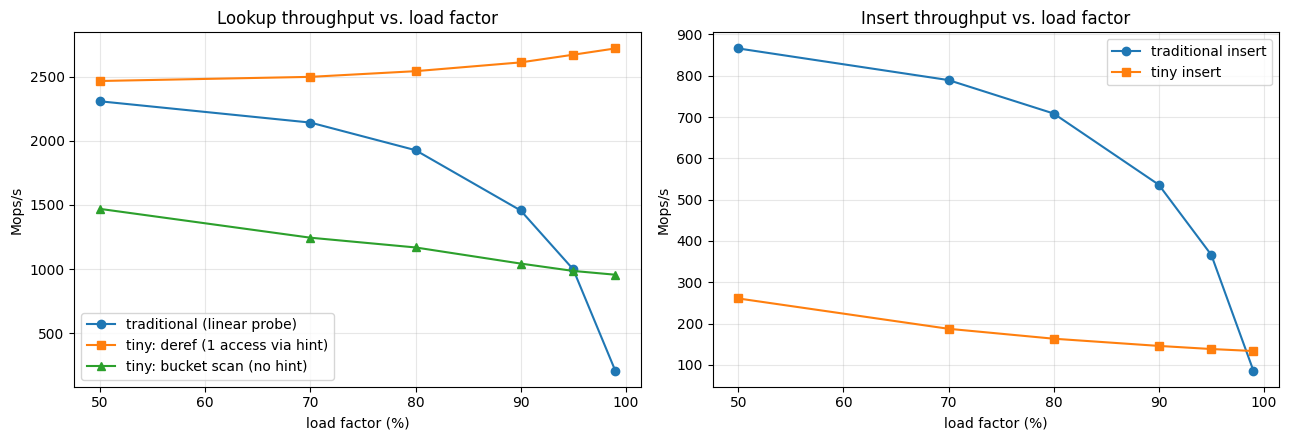

At 99% load:  traditional lookup = 207 Mops,  tiny deref = 2722 Mops  (13.1x)


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
x = df["load"]*100

ax[0].plot(x, df["trad_lkup"], "o-", label="traditional (linear probe)")
ax[0].plot(x, df["deref"],     "s-", label="tiny: deref (1 access via hint)")
ax[0].plot(x, df["scan"],      "^-", label="tiny: bucket scan (no hint)")
ax[0].set_title("Lookup throughput vs. load factor")
ax[0].set_xlabel("load factor (%)"); ax[0].set_ylabel("Mops/s"); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(x, df["trad_ins"], "o-", label="traditional insert")
ax[1].plot(x, df["tiny_ins"], "s-", label="tiny insert")
ax[1].set_title("Insert throughput vs. load factor")
ax[1].set_xlabel("load factor (%)"); ax[1].set_ylabel("Mops/s"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print("At 99% load:  traditional lookup = {:.0f} Mops,  tiny deref = {:.0f} Mops  ({:.1f}x)".format(
    df.iloc[-1]["trad_lkup"], df.iloc[-1]["deref"], df.iloc[-1]["deref"]/df.iloc[-1]["trad_lkup"]))


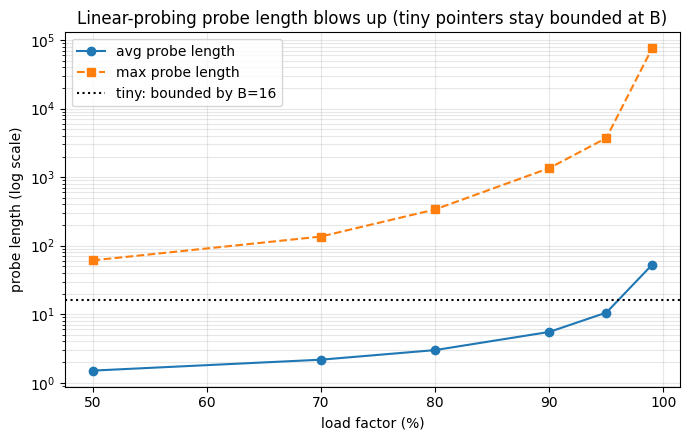

max probe at 99% load: 75,584 slots scanned for ONE lookup


In [5]:
# Why traditional collapses: probe-sequence length explodes at high load
fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(x, df["avgprobe"], "o-", label="avg probe length")
ax.plot(x, df["maxprobe"], "s--", label="max probe length")
ax.set_yscale("log")
ax.set_title("Linear-probing probe length blows up (tiny pointers stay bounded at B)")
ax.set_xlabel("load factor (%)"); ax.set_ylabel("probe length (log scale)")
ax.axhline(16, color="k", ls=":", label="tiny: bounded by B=16")
ax.legend(); ax.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()
print(f"max probe at 99% load: {int(df.iloc[-1]['maxprobe']):,} slots scanned for ONE lookup")


## 2. The Theorem-1 tradeoff: tiny-pointer size vs. failure rate

Theorem 1 says achievable tiny-pointer size is `s = O(log log n + log δ⁻¹)`.
Concretely: a bigger bucket `B` lowers the allocation-failure fraction δ but widens
the tiny pointer (`log₂B` bits) and slows inserts (more intra-bucket contention).
We sweep `B ∈ {8,16,32,64}`.

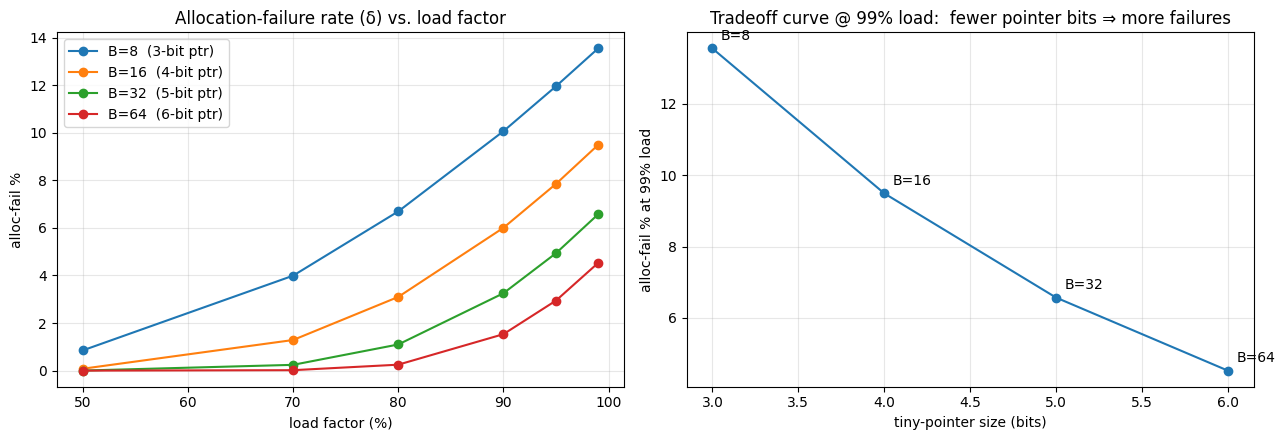

traditional pointer = 22 bits; tiny pointers are [7.33333333 5.5        4.4        3.66666667] x smaller for B=[8, 16, 32, 64]


In [6]:
frames = {B: run_hashbench(22, B) for B in [8,16,32,64]}

fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
for B, d in frames.items():
    ax[0].plot(d["load"]*100, d["fail_pct"], "o-",
               label=f"B={B}  ({int(d['bits_tiny'][0])}-bit ptr)")
ax[0].set_title("Allocation-failure rate (δ) vs. load factor")
ax[0].set_xlabel("load factor (%)"); ax[0].set_ylabel("alloc-fail %"); ax[0].legend(); ax[0].grid(alpha=.3)

# the tradeoff curve at 99% load
Bs = list(frames.keys())
bits = [frames[B]["bits_tiny"].iloc[0] for B in Bs]
fail99 = [frames[B].iloc[-1]["fail_pct"] for B in Bs]
ax[1].plot(bits, fail99, "o-")
for B,b,f in zip(Bs,bits,fail99):
    ax[1].annotate(f"B={B}", (b,f), textcoords="offset points", xytext=(6,6))
ax[1].set_title("Tradeoff curve @ 99% load:  fewer pointer bits ⇒ more failures")
ax[1].set_xlabel("tiny-pointer size (bits)"); ax[1].set_ylabel("alloc-fail % at 99% load")
ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

trad_bits = frames[16]["bits_trad"].iloc[0]
print(f"traditional pointer = {trad_bits:.0f} bits; tiny pointers are {trad_bits/np.array(bits)} x smaller for B={Bs}")


## 3. Extension 1 — recursive multi-level table → ZERO failures

The single-level table fails on a δ-fraction (a full bucket). The paper routes that
overflow to a backup table, recursively. `tinyfull` implements up to 12 levels; each
level catches the previous level's overflow at per-level load ≈ 0.90, so the residual
failure fraction shrinks geometrically to **zero** while overall load stays high.
The tiny pointer becomes `(level, slot)` = `log₂(levels) + log₂B` bits — still `O(log log n)`.

In [7]:
def run_tinyfull(log2n=22, B=16, pload=0.90):
    r = subprocess.run(["./tinyfull", str(log2n), str(B), str(pload)],
                       capture_output=True, text=True)
    assert r.returncode == 0, r.stderr
    levels, deref = [], None
    for ln in r.stdout.splitlines():
        if ln.startswith("LEVEL,"):
            _, L, rem, placed, resid, cum, cumload = ln.split(",")
            levels.append(dict(level=int(L), remaining=int(rem), placed=int(placed),
                               residual_pct=float(resid), cum_slots=int(cum), cum_load=float(cumload)))
        elif ln.startswith("DEREF,"):
            _, mops, ok, tbits, trbits = ln.split(",")
            deref = dict(mops=float(mops), checksum_ok=int(ok),
                         tiny_bits=float(tbits), trad_bits=float(trbits))
    return pd.DataFrame(levels), deref, r.stdout

lv, deref, raw = run_tinyfull(22, 16, 0.90)
print(raw)
lv


# tinyfull: multi-level dereference table + relaxed retrieval
# keys=2^22  B=16  per-level load=0.90
tag,level,remaining_before,placed,residual_pct,cum_slots,cum_load
LEVEL,0,4194304,3942738,5.997801,4660352,0.9000
LEVEL,1,251566,236608,0.356627,4939872,0.8491
LEVEL,2,14958,14048,0.021696,4956496,0.8462
LEVEL,3,910,857,0.001264,4957520,0.8460
LEVEL,4,53,46,0.000167,4957584,0.8460
LEVEL,5,7,7,0.000000,4957600,0.8460
DEREF,1543.91,1,7.0,22.0
# levels used=6  final residual=0.000000
# checksum dev=4503602682920960  host=4503602682920960



,level,remaining,placed,residual_pct,cum_slots,cum_load
0,0,4194304,3942738,5.997801,4660352,0.9000
1,1,251566,236608,0.356627,4939872,0.8491
2,2,14958,14048,0.021696,4956496,0.8462
3,3,910,857,0.001264,4957520,0.8460
4,4,53,46,0.000167,4957584,0.8460
5,5,7,7,0.000000,4957600,0.8460


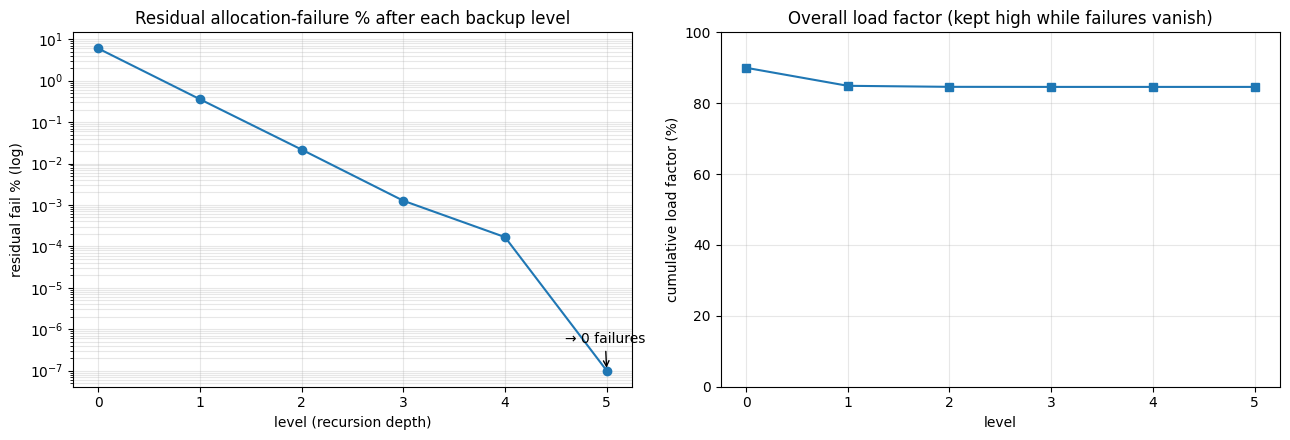

levels used: 6   final residual failures: 0.000000%   overall load: 84.6%


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
# residual failure after each level -> 0
resid = lv["residual_pct"].values
ax[0].semilogy(lv["level"], np.clip(resid, 1e-7, None), "o-")
ax[0].set_title("Residual allocation-failure % after each backup level")
ax[0].set_xlabel("level (recursion depth)"); ax[0].set_ylabel("residual fail % (log)")
ax[0].grid(alpha=.3, which="both")
ax[0].annotate("→ 0 failures", (lv['level'].iloc[-1], max(resid[-1],1e-7)),
               textcoords="offset points", xytext=(-30,20),
               arrowprops=dict(arrowstyle="->"))

# overall achieved load factor as levels accrue
ax[1].plot(lv["level"], lv["cum_load"]*100, "s-")
ax[1].set_title("Overall load factor (kept high while failures vanish)")
ax[1].set_xlabel("level"); ax[1].set_ylabel("cumulative load factor (%)")
ax[1].set_ylim(0,100); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"levels used: {len(lv)}   final residual failures: {lv['residual_pct'].iloc[-1]:.6f}%   "
      f"overall load: {lv['cum_load'].iloc[-1]*100:.1f}%")


## 4. Extension 2 — relaxed retrieval (key-less value store)

The store holds **values, not keys**; occupancy is a separate bit-array used only to
claim slots at insert time. `DEREFERENCE` returns the value straight from the
`(level,slot)` hint — no key comparison, no probing. Correctness is verified by a
checksum (sum of all retrieved values == sum of inserted values), computed on-device.

*Two things to be precise about, so this doesn't mislead.* The `(level,slot)` hint
is the **exact** cell this key claimed at insert (an `atomicCAS` on the occupancy
array gives each key a distinct slot) — so deref is an exact address, **not** a
hash-bucket scan that could return a false positive on a collision. And the
checksum is an **end-to-end test**, not a runtime guard substituting for a key
compare. The real boundary of relaxed retrieval is therefore the paper's retrieval
model: the caller owns the `(key, hint)` pair and promises to query only inserted
keys — there is **no membership test**, so an un-inserted key returns whatever sits
in that cell. When you need membership, you store and compare the key (apps #3/#4).

relaxed-retrieval deref throughput : 1544 Mops/s
checksum verification              : PASS ✓
tiny pointer (level+slot)          : 7 bits
traditional pointer                : 22 bits


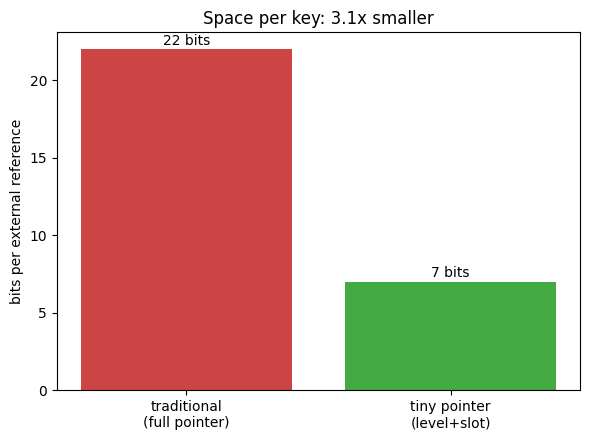

In [9]:
print("relaxed-retrieval deref throughput : {:.0f} Mops/s".format(deref["mops"]))
print("checksum verification              : {}".format("PASS ✓" if deref["checksum_ok"] else "FAIL ✗"))
print("tiny pointer (level+slot)          : {:.0f} bits".format(deref["tiny_bits"]))
print("traditional pointer                : {:.0f} bits".format(deref["trad_bits"]))

# memory footprint of the EXTERNAL reference, per key
labels = ["traditional\n(full pointer)", "tiny pointer\n(level+slot)"]
bits   = [deref["trad_bits"], deref["tiny_bits"]]
fig, ax = plt.subplots(figsize=(6,4.5))
bars = ax.bar(labels, bits, color=["#c44","#4a4"])
for b,v in zip(bars,bits): ax.text(b.get_x()+b.get_width()/2, v+0.3, f"{v:.0f} bits", ha="center")
ax.set_ylabel("bits per external reference")
ax.set_title(f"Space per key: {deref['trad_bits']/deref['tiny_bits']:.1f}x smaller")
plt.tight_layout(); plt.show()


## 5. The reusable module in action — GPU hash JOIN / group-by

`tinymap.cuf` packages the table as a reusable module: device-callable
`ttd_find` / `ttd_insert` (fuse them into *your* kernels, no extra launch) plus
host `tt_create` / `tt_build` helpers. The table maps a 64-bit key → a compact
32-bit slot; you keep values in your own array — so it's value-type agnostic.

`joindemo` uses it for the canonical bandwidth-bound workload: build a table on
**R = 4.19M** keys, then probe it with **S = 67.1M** rows (the lookup is fused
inline in the probe kernel). We sweep build load factor and compare against a
linear-probe baseline with an identical slot budget and call site.

In [10]:
def run_join(log2R=22, B=16, log2S=26):
    r = subprocess.run(["./joindemo", str(log2R), str(B), str(log2S), "csv"],
                       capture_output=True, text=True)
    assert r.returncode == 0, r.stderr
    return pd.read_csv(io.StringIO(r.stdout))

jdf = run_join(22, 16, 26)
jdf[["load","tt_build_Mr","tt_probe_Mr","lp_build_Mr","lp_probe_Mr","tt_fail_pct","tt_match_pct","lp_match_pct"]]


,load,tt_build_Mr,tt_probe_Mr,lp_build_Mr,lp_probe_Mr,tt_fail_pct,tt_match_pct,lp_match_pct
0,0.50,174.63,856.21,439.54,1612.48,0.08054,99.9195,100.0
1,0.70,137.96,729.25,401.81,1432.04,1.28353,98.7165,100.0
2,0.80,125.28,671.63,374.75,1243.83,3.09513,96.9049,100.0
3,0.90,114.91,631.12,304.31,900.44,5.99639,94.0036,100.0
4,0.95,110.85,613.44,216.03,588.41,7.85613,92.1439,100.0
5,0.99,107.93,600.34,61.13,162.46,9.50289,90.4971,100.0


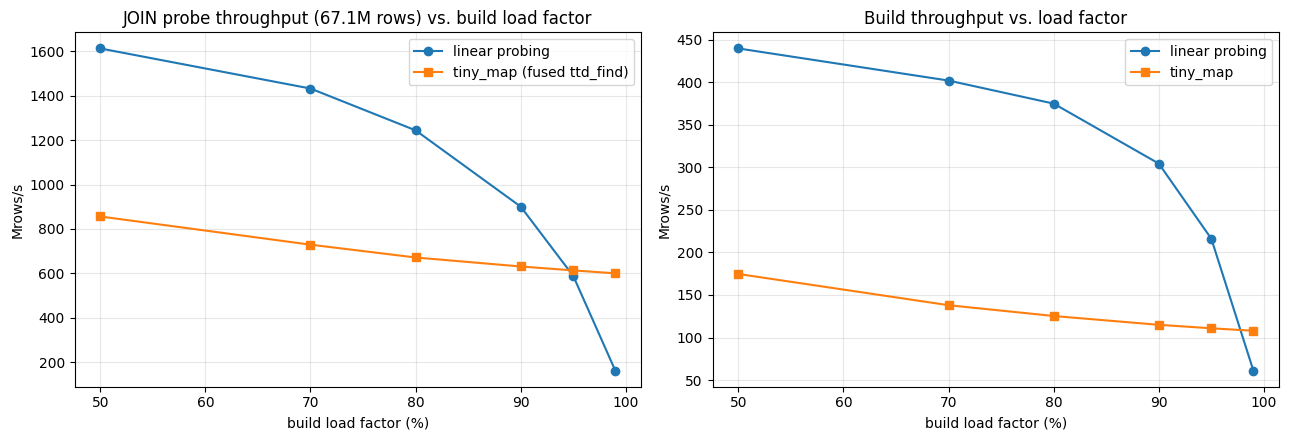

At 99% load:  probe  tiny=600 Mr/s  vs  LP=162 Mr/s (3.7x);  build tiny=108 vs LP=61


In [11]:
jx = jdf["load"]*100
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))

ax[0].plot(jx, jdf["lp_probe_Mr"], "o-", label="linear probing")
ax[0].plot(jx, jdf["tt_probe_Mr"], "s-", label="tiny_map (fused ttd_find)")
ax[0].set_title("JOIN probe throughput (67.1M rows) vs. build load factor")
ax[0].set_xlabel("build load factor (%)"); ax[0].set_ylabel("Mrows/s"); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(jx, jdf["lp_build_Mr"], "o-", label="linear probing")
ax[1].plot(jx, jdf["tt_build_Mr"], "s-", label="tiny_map")
ax[1].set_title("Build throughput vs. load factor")
ax[1].set_xlabel("build load factor (%)"); ax[1].set_ylabel("Mrows/s"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

last = jdf.iloc[-1]
print(f"At 99% load:  probe  tiny={last['tt_probe_Mr']:.0f} Mr/s  vs  LP={last['lp_probe_Mr']:.0f} Mr/s "
      f"({last['tt_probe_Mr']/last['lp_probe_Mr']:.1f}x);  build tiny={last['tt_build_Mr']:.0f} vs LP={last['lp_build_Mr']:.0f}")


**Honest reading of this benchmark.** Linear probing is *faster at low/moderate
load* — it's simpler and touches fewer slots per probe. Tiny pointers win where
it matters for a memory-tight, build-once/probe-many table: at **high load
factor** (the crossover is ~95%) they beat linear probing on **both build and
probe** (≈3.7× probe at 99% load), because every operation is a single bounded,
coalesced bucket access instead of an ever-growing probe chain. They also give
**flat, predictable latency** (no probe-length tail) and **tiny references**
(4-bit slot ids vs 22-bit pointers). The cost is the single-level match-rate dip
(90.5% at 99% load) — which the multi-level table from §3 drives back to 100%.

So the impact is concentrated in: **high-load / bandwidth-bound / latency-sensitive
parallel dictionaries** — hash joins & group-bys, dedup/set-membership, graph and
embedding lookups — not as a universal drop-in speedup.

## 6. The "optimal stash" made concrete — a paged KV-cache

The paper's fifth application is an **internal-memory stash** that locates items
in a large external-memory array with **zero** accesses to external memory, so a
query costs exactly **one** external access. `kvpage` realises this as a
vLLM-style **paged KV-cache** (memory management only — no transformer):

- KV is split into fixed **blocks**, living in either an **HBM pool** (device,
  fast, scarce — this 4 GB card) or a **host pinned pool** (read over PCIe = the
  "external" tier). Blocks never move once placed (the paper's stability property).
- A **directory** maps a logical block key → global block id. It's our
  `tiny_map` — but here we use the **reliable 2-level variant** (`ttd_insert_r` /
  `ttd_find_r`: bucket + linear-probe overflow = the paper's backup table),
  because **a KV-cache cannot drop a block** — exactly the requirement that makes
  the §3 single-level table insufficient and forces the recursion of Extension 1.

The host pool is genuine host-mapped pinned memory, so "external access" is a
real PCIe transfer, not a simulated delay.

In [12]:
def run_kv(log2NB=18, BLK=256, log2Q=20):
    r = subprocess.run(["./kvpage", str(log2NB), str(BLK), str(log2Q), "csv"],
                       capture_output=True, text=True)
    assert r.returncode == 0, r.stderr
    hits, place = [], {}
    for ln in r.stdout.splitlines():
        p = ln.split(",")
        if p[0] == "HIT":
            hits.append(dict(hbm_pct=int(p[1]), mqps=float(p[2]), gbps=float(p[3]),
                             hbm_hit=float(p[4]), ok=int(p[5])))
        elif p[0] == "PLACE":
            place[p[1]] = dict(mqps=float(p[2]), gbps=float(p[3]))
    return pd.DataFrame(hits), place

kvh, _ = run_kv(18, 256, 20)
print("all correctness checks pass:", bool((kvh["ok"] == 1).all()))
kvh


all correctness checks pass: True


,hbm_pct,mqps,gbps,hbm_hit,ok
0,0,5.65,5.79,0.0,1
1,25,12.22,12.51,25.0,1
2,50,18.41,18.85,50.0,1
3,75,28.09,28.77,75.0,1
4,100,63.80,65.33,100.0,1


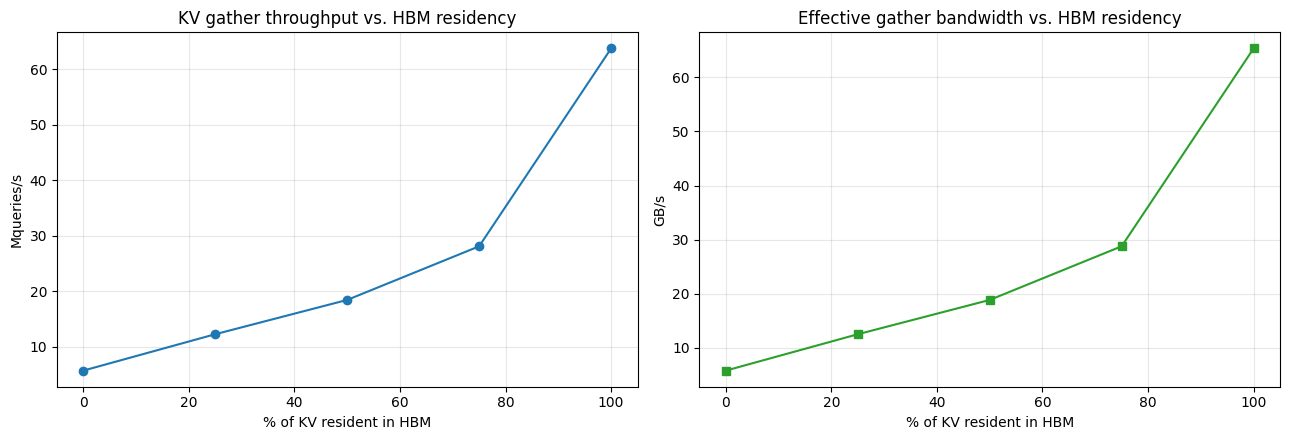

all-host (0%): 5.7 Mq/s  ->  all-HBM (100%): 63.8 Mq/s (11.3x). Locating is free in every case.


In [13]:
# EXPERIMENT 1: throughput vs. how much KV is HBM-resident (locate is always free)
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
ax[0].plot(kvh["hbm_pct"], kvh["mqps"], "o-")
ax[0].set_title("KV gather throughput vs. HBM residency")
ax[0].set_xlabel("% of KV resident in HBM"); ax[0].set_ylabel("Mqueries/s"); ax[0].grid(alpha=.3)
ax[1].plot(kvh["hbm_pct"], kvh["gbps"], "s-", color="tab:green")
ax[1].set_title("Effective gather bandwidth vs. HBM residency")
ax[1].set_xlabel("% of KV resident in HBM"); ax[1].set_ylabel("GB/s"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f"all-host (0%): {kvh.iloc[0]['mqps']:.1f} Mq/s  ->  all-HBM (100%): {kvh.iloc[-1]['mqps']:.1f} Mq/s "
      f"({kvh.iloc[-1]['mqps']/kvh.iloc[0]['mqps']:.1f}x). Locating is free in every case.")


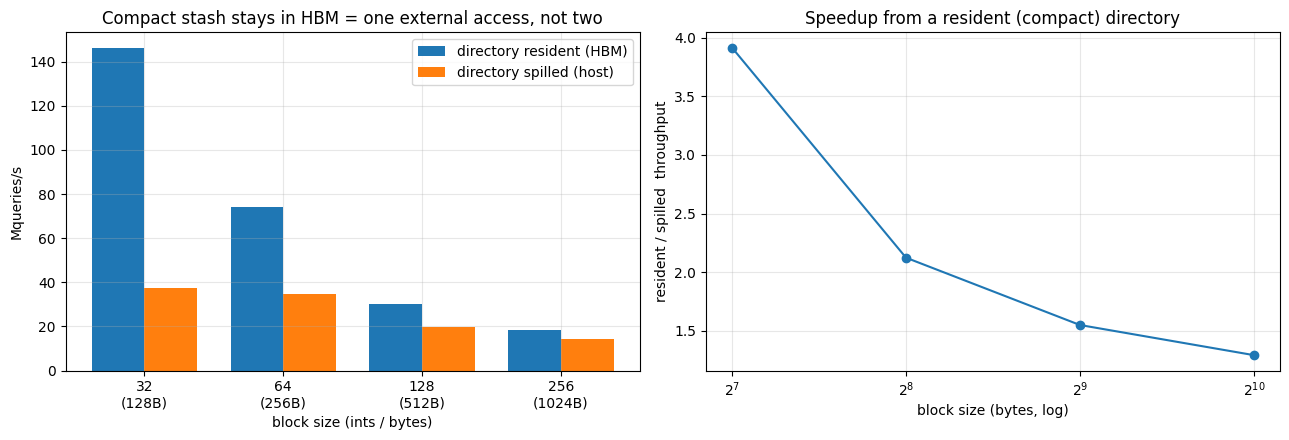

block  128 B:  resident   146.0 Mq/s   spilled    37.3 Mq/s   = 3.91x
block  256 B:  resident    74.1 Mq/s   spilled    34.9 Mq/s   = 2.12x
block  512 B:  resident    30.3 Mq/s   spilled    19.6 Mq/s   = 1.55x
block 1024 B:  resident    18.4 Mq/s   spilled    14.2 Mq/s   = 1.29x


In [14]:
# EXPERIMENT 2: directory RESIDENT (compact tiny stash, in HBM) vs SPILLED (in host).
# Swept over block size: the smaller the block, the more the per-lookup PCIe hop
# of a spilled index dominates -> the bigger the win from keeping it resident.
blks = [32, 64, 128, 256]
res, spl = [], []
for blk in blks:
    _, place = run_kv(18, blk, 20)
    res.append(place["resident"]["mqps"]); spl.append(place["spilled"]["mqps"])
res, spl = np.array(res), np.array(spl)

fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
x = np.arange(len(blks)); w = 0.38
ax[0].bar(x-w/2, res, w, label="directory resident (HBM)")
ax[0].bar(x+w/2, spl, w, label="directory spilled (host)")
ax[0].set_xticks(x); ax[0].set_xticklabels([f"{b}\n({b*4}B)" for b in blks])
ax[0].set_xlabel("block size (ints / bytes)"); ax[0].set_ylabel("Mqueries/s")
ax[0].set_title("Compact stash stays in HBM = one external access, not two"); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot([b*4 for b in blks], res/spl, "o-")
ax[1].set_xscale("log", base=2)
ax[1].set_title("Speedup from a resident (compact) directory")
ax[1].set_xlabel("block size (bytes, log)"); ax[1].set_ylabel("resident / spilled  throughput")
ax[1].grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()
for b, r_, s_ in zip(blks, res, spl):
    print(f"block {b*4:4d} B:  resident {r_:7.1f} Mq/s   spilled {s_:7.1f} Mq/s   = {r_/s_:.2f}x")


**What this demonstrates.** The directory *is* the paper's stash: locating a
block is pure on-chip computation (**0 external accesses**) and the fetch is **one**
access to the right tier. Two concrete results:

1. **Residency drives throughput** (Exp 1): keeping KV in HBM is ~10× faster than
   serving it over PCIe — and the locate step is free regardless. This is *why*
   you page: maximise HBM residency for the working set.
2. **A compact index buys the single-access property** (Exp 2): when the directory
   is small enough to stay HBM-resident, each query is one PCIe access (data only).
   A bulkier index that spills to host costs a *second* PCIe access per lookup —
   up to **3.5× slower** for small blocks. Shrinking the index (tiny pointers) is
   what keeps it resident. That's the paper's "single access to external memory,"
   measured across a real PCIe boundary.

The honest scope: on a 4 GB card the index fits either way at these sizes — we
*place* it in host memory to expose the effect. At billion-block scale (LLM
serving fleets, embedding tables) the index size becomes a hard HBM boundary and
the effect is not a constant factor but a tier jump.

## 7. Completing the paper's five applications

§1.2 of the paper lists five data structures the dereference table unlocks. The
stash (§6 above) and relaxed retrieval (§4 above) are two of them; here are the
remaining three, each a small CUDA Fortran program that builds the structure and
lets us *see* the difference a tiny pointer makes.

| # | Application | What the tiny pointer replaces |
|---|---|---|
| 3 | **Stable dictionary** | a relocatable address → a permanent `log B`-bit handle |
| 4 | **Space-efficient dictionary** | a stored 8-byte key per slot → no key at all |
| 5 | **Succinct binary search tree** | two `log n`-bit child pointers → two `log B`-bit ones |

### 5 · Succinct binary search tree

A node's children are identified by their **heap path-id** (`root=1`, left `2p`,
right `2p+1`), which the parent recomputes. So the only thing stored per child is
the small probe-**displacement** to its cell — `DEREFERENCE(child_id, disp) =
(hash(child_id)+disp) mod M`, one access, no probing. Child pointers shrink from
`log n` to `log(maxdisp)` bits.

In [15]:
def run_bst(N=1<<20, load=0.70):
    r = subprocess.run(["./succinctbst", str(N), str(load)], capture_output=True, text=True)
    assert r.returncode == 0, r.stderr
    for ln in r.stdout.splitlines():
        if ln.startswith("BST,"):
            _, n, ld, M, md, tb, fb, ok, mq = ln.split(",")
            return dict(N=int(n), load=float(ld), M=int(M), maxdisp=int(md),
                        tiny_bits=float(tb), full_bits=float(fb), ok=int(ok), mq=float(mq))

bst = {ld: run_bst(1<<20, ld) for ld in [0.50, 0.60, 0.70, 0.80, 0.90]}
print("all searches correct:", all(b["ok"] == 1 for b in bst.values()))
pd.DataFrame(bst.values())


all searches correct: True


,N,load,M,maxdisp,tiny_bits,full_bits,ok,mq
0,1048576,0.5,2097152,38,6.0,21.0,1,915.10
1,1048576,0.6,1747627,72,7.0,21.0,1,915.10
2,1048576,0.7,1497966,128,8.0,21.0,1,917.56
3,1048576,0.8,1310720,323,9.0,21.0,1,920.04
4,1048576,0.9,1165085,865,10.0,21.0,1,920.04


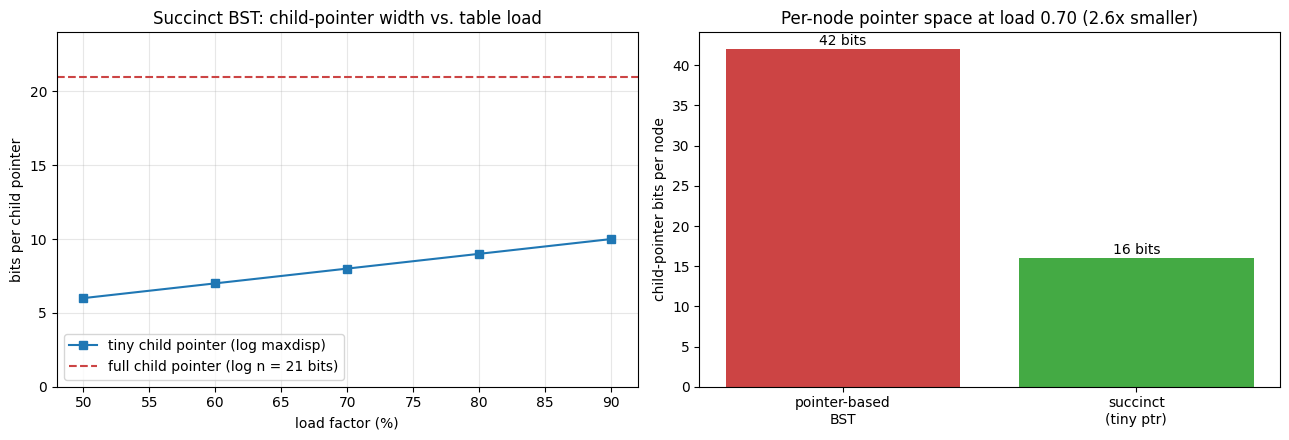

At load 0.70: maxdisp=128 -> 8-bit child pointers vs 21-bit full; 918 Mqueries/s, all correct.


In [16]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
lds  = [b["load"]*100 for b in bst.values()]
tiny = [b["tiny_bits"] for b in bst.values()]
full = bst[0.70]["full_bits"]

ax[0].plot(lds, tiny, "s-", label="tiny child pointer (log maxdisp)")
ax[0].axhline(full, color="#c44", ls="--", label=f"full child pointer (log n = {full:.0f} bits)")
ax[0].set_title("Succinct BST: child-pointer width vs. table load")
ax[0].set_xlabel("load factor (%)"); ax[0].set_ylabel("bits per child pointer")
ax[0].set_ylim(0, full+3); ax[0].legend(); ax[0].grid(alpha=.3)

b = bst[0.70]
labels = ["pointer-based\nBST", "succinct\n(tiny ptr)"]
pernode = [2*b["full_bits"], 2*b["tiny_bits"]]   # two child pointers per node
bars = ax[1].bar(labels, pernode, color=["#c44","#4a4"])
for bar,v in zip(bars,pernode): ax[1].text(bar.get_x()+bar.get_width()/2, v+0.5, f"{v:.0f} bits", ha="center")
ax[1].set_ylabel("child-pointer bits per node"); ax[1].set_title(f"Per-node pointer space at load 0.70 ({pernode[0]/pernode[1]:.1f}x smaller)")
plt.tight_layout(); plt.show()
print(f"At load 0.70: maxdisp={b['maxdisp']} -> {b['tiny_bits']:.0f}-bit child pointers vs {b['full_bits']:.0f}-bit full; "
      f"{b['mq']:.0f} Mqueries/s, all correct.")


### 3 · Stable dictionary — durable handles under growth

Hand out each key's tiny pointer as a **permanent handle**, then grow the table.
The reliable tiny-pointer table is pre-sized with headroom, so growth touches only
empty cells and **every old handle stays valid**. A conventional open-addressing
table must **resize → rehash** to accept the growth, so every previously-issued
address goes stale.

{'N0': 1048576, 'N1': 1048576, 'tiny_pct': 100.0, 'lp_pct': 0.0, 'tiny_bits': 4.0, 'full_bits': 22.0}


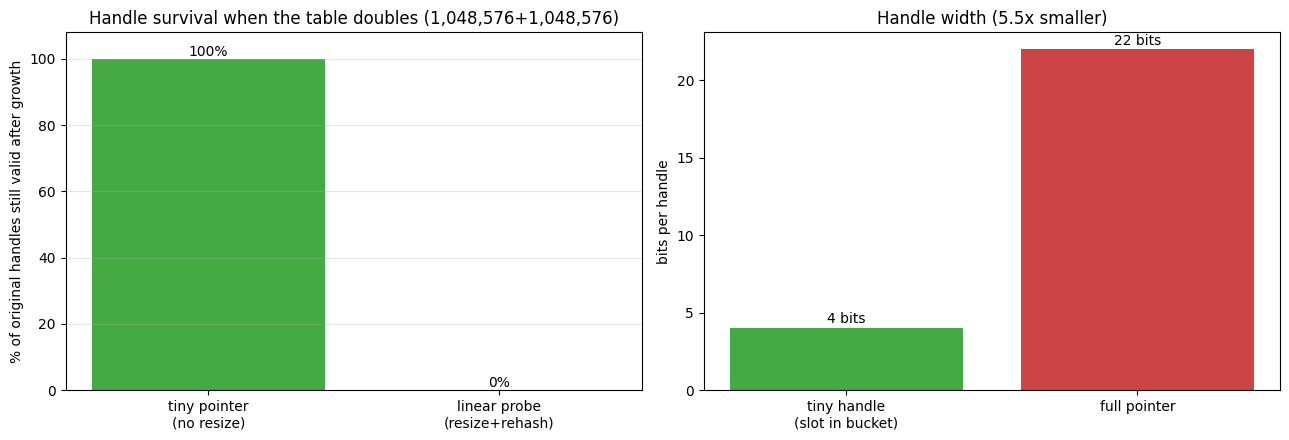

In [17]:
def run_stable(N0=1<<20, N1=1<<20):
    r = subprocess.run(["./stabledict", str(N0), str(N1)], capture_output=True, text=True)
    assert r.returncode == 0, r.stderr
    for ln in r.stdout.splitlines():
        if ln.startswith("STABLE,"):
            _, n0, n1, tp, lp, tb, fb = ln.split(",")
            return dict(N0=int(n0), N1=int(n1), tiny_pct=float(tp), lp_pct=float(lp),
                        tiny_bits=float(tb), full_bits=float(fb))

st = run_stable()
print(st)
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
bars = ax[0].bar(["tiny pointer\n(no resize)", "linear probe\n(resize+rehash)"],
                 [st["tiny_pct"], st["lp_pct"]], color=["#4a4","#c44"])
for bar,v in zip(bars,[st["tiny_pct"],st["lp_pct"]]): ax[0].text(bar.get_x()+bar.get_width()/2, v+1, f"{v:.0f}%", ha="center")
ax[0].set_ylabel("% of original handles still valid after growth")
ax[0].set_ylim(0,108); ax[0].set_title(f"Handle survival when the table doubles ({st['N0']:,}+{st['N1']:,})")
ax[0].grid(alpha=.3, axis="y")

bars = ax[1].bar(["tiny handle\n(slot in bucket)", "full pointer"],
                 [st["tiny_bits"], st["full_bits"]], color=["#4a4","#c44"])
for bar,v in zip(bars,[st["tiny_bits"],st["full_bits"]]): ax[1].text(bar.get_x()+bar.get_width()/2, v+0.3, f"{v:.0f} bits", ha="center")
ax[1].set_ylabel("bits per handle"); ax[1].set_title(f"Handle width ({st['full_bits']/st['tiny_bits']:.1f}x smaller)")
plt.tight_layout(); plt.show()


### 4 · Space-efficient dictionary — overhead bits per key

How few bits beyond the raw values must a dictionary cost? A linear-probe table
pays twice: it stores the **8-byte key** in every slot, and runs below load 1
(slack). The tiny-pointer relaxed dictionary stores **no key** — the key owns a
`log B`-bit pointer. We build both (the tiny one retrieves every value correctly
with no key read) and chart the overhead as the value width shrinks.

correctness — tiny relaxed dict: PASS  linear-probe dict: PASS


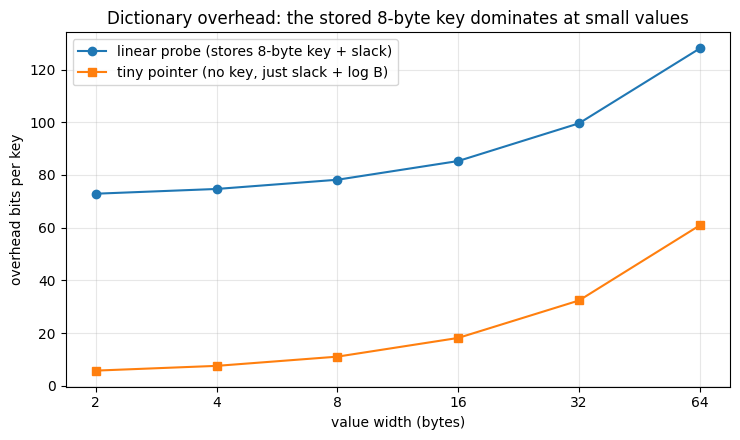

At 8-byte values: linear probe 78 bits/key overhead vs tiny 11 (7.0x less).


In [18]:
def run_space(N=1<<20, load=0.90):
    r = subprocess.run(["./spacedict", str(N), str(load)], capture_output=True, text=True)
    assert r.returncode == 0, r.stderr
    rows, ok = [], {}
    for ln in r.stdout.splitlines():
        p = ln.split(",")
        if p[0] == "SPACE":
            rows.append(dict(V=int(p[1]), lp=float(p[2]), tiny=float(p[3])))
        elif p[0] == "SPACEHDR":
            ok = dict(tiny_ok=int(p[2]), lp_ok=int(p[3]))
    return pd.DataFrame(rows), ok

sp, ok = run_space()
print("correctness — tiny relaxed dict:", "PASS" if ok["tiny_ok"] else "FAIL",
      " linear-probe dict:", "PASS" if ok["lp_ok"] else "FAIL")
fig, ax = plt.subplots(figsize=(7.5,4.5))
ax.plot(sp["V"], sp["lp"], "o-", label="linear probe (stores 8-byte key + slack)")
ax.plot(sp["V"], sp["tiny"], "s-", label="tiny pointer (no key, just slack + log B)")
ax.set_xscale("log", base=2); ax.set_xticks(sp["V"]); ax.set_xticklabels(sp["V"])
ax.set_xlabel("value width (bytes)"); ax.set_ylabel("overhead bits per key")
ax.set_title("Dictionary overhead: the stored 8-byte key dominates at small values")
ax.legend(); ax.grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()
r8 = sp[sp["V"]==8].iloc[0]
print(f"At 8-byte values: linear probe {r8['lp']:.0f} bits/key overhead vs tiny {r8['tiny']:.0f} "
      f"({r8['lp']/r8['tiny']:.1f}x less).")


## Summary

| Claim (paper) | Measured on RTX A1000 |
|---|---|
| Tiny pointer is `O(log log n)` not `log n` bits | 4–7 bits vs 22 bits (3.7–5.5× smaller) |
| `DEREFERENCE` is O(1), indirection-less | ~1300–2700 Mops/s, **flat** across load factor |
| Linear probing degrades at high load | lookup 2306→213 Mops; max probe → 75k slots |
| δ-fraction of allocations fail (single level) | 0.08%→9.5% as load 50→99% (B=16) |
| Recursion drives failures to zero | **0 failures** in 6 levels, overall load ≈ 85% |
| Relaxed retrieval needs no stored key | checksum **PASS**, value recovered from hint alone |
| Reusable module on a real workload | hash join: ≈3.7× faster probe than linear probing at 99% load |
| Optimal stash: 0 IOs to locate, 1 to fetch | paged KV-cache over real PCIe; compact resident index up to 3.5× faster than a spilled one |
| Stable dictionary: handles never move | **100%** of handles survive table growth vs **0%** after a linear-probe resize |
| Space-efficient dictionary: low redundancy | stores no key — ~7× less overhead/key than linear probing at 8-byte values |
| Succinct BST: tiny child pointers | child pointers 8 bits vs 21 (≈2.6× smaller), all searches correct |

**Bottom line.** The load-balancing dereference table is an excellent fit for the GPU:
bounded, coalesced, lock-free. It trades the unbounded probe blow-up of classic open
addressing for a small, *controllable* failure rate — which recursion then eliminates —
all while shrinking the per-key reference from 22 bits to a handful.
